# Extração dos metadados dos processos judiciais
##### do Tribunal Regional Federal da 2a. Região
##### Coorte: Todos os processos finalizados durante o ano de 2025

In [3]:
import requests
import json
import time
import os
from google.colab import drive
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES DA API E PARÂMETROS
# =============================================================================
API_KEY = "APIKey cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw=="
HEADERS = {"Authorization": API_KEY, "Content-Type": "application/json"}
URL = "https://api-publica.datajud.cnj.jus.br/api_publica_trf2/_search"

# Período de interesse para a Baixa (Ajuste conforme necessário)
DATA_INICIO = "2025-01-01T00:00:00.000Z"
DATA_FIM = "2025-12-31T23:59:59.999Z"

# A query no ES traz uma pré-seleção: processos com *algum* movimento 22 e *algum* movimento em 2025.
# O filtro real e preciso será feito pelo Python logo abaixo.
QUERY = {
    "bool": {
        "must": [
            {"match": {"movimentos.codigo": 22}},
            {"range": {"movimentos.dataHora": {
                "gte": DATA_INICIO,
                "lte": DATA_FIM
            }}}
        ]
    }
}

PAGE_SIZE = 1000
SLEEP = 1  # intervalo cortês entre chamadas

# Salvar no Colab local e no Google Drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILENAME = "processos_trf2_baixa_definitiva_2025_filtro22.jsonl"
OUT_FILE_LOCAL = os.path.join('/content', FILENAME)
OUT_FILE_DRIVE = os.path.join(OUTPUT_DIR, FILENAME)

def post(body, tries=5):
    """Executa a requisição POST com controle de retentativas (Retry-After e 429)."""
    while True:
        for i in range(tries):
            try:
                r = requests.post(URL, headers=HEADERS, json=body, timeout=60)
                if r.status_code == 200:
                    return r.json()
                if r.status_code == 429:
                    time.sleep(int(r.headers.get("Retry-After", 2 ** i)))
                    continue
                raise RuntimeError(f"HTTP {r.status_code}: {r.text}")
            except requests.exceptions.RequestException as e:
                print(f"Erro de conexão: {e}. Tentando novamente...")
                time.sleep(5)
        print("Muitas tentativas falhas — aguardando 60s antes de tentar novamente...")
        time.sleep(60)

def passou_no_filtro(processo):
    """
    Garante que o movimento com código 22 ocorreu DENTRO do período estipulado.
    Isso corrige a limitação do Elasticsearch do DataJud (flat array objects).
    """
    movimentos = processo.get("movimentos", [])

    for mov in movimentos:
        # Extrai o código (alguns tribunais colocam direto no mov, outros no movimentoNacional)
        codigo = mov.get("codigo")
        if codigo is None and "movimentoNacional" in mov:
            codigo = mov["movimentoNacional"].get("codigo")

        # Se for o movimento de baixa definitiva (22)
        if codigo == 22:
            data_hora = mov.get("dataHora", "")
            # Verifica se a data exata DESTE movimento está em 2025
            if DATA_INICIO <= data_hora <= DATA_FIM:
                # Opcional: Se você quiser garantir que é estritamente o ÚLTIMO movimento cronológico
                # do processo, você pode ordenar o array e validar. Mas cuidado, pois muitas
                # vezes ocorre um "Arquivamento Definitivo (246)" logo após a baixa (22).
                # Desta forma, garantimos que a BAIXA efetivamente ocorreu em 2025.
                return True

    return False

print("Iniciando consulta ao DataJud...")
resp = post({"size": 0, "track_total_hits": True, "query": QUERY})
total_es = resp["hits"]["total"]["value"]
print(f"TOTAL pré-selecionado pelo Elasticsearch: {total_es} (Sujeito a filtro rigoroso local)")

if os.path.exists(OUT_FILE_DRIVE) and not os.path.exists(OUT_FILE_LOCAL):
    print("Sincronizando arquivo do Drive para o ambiente local...")
    with open(OUT_FILE_DRIVE, "r", encoding="utf-8") as fsrc, \
         open(OUT_FILE_LOCAL, "w", encoding="utf-8") as fdst:
        fdst.write(fsrc.read())

coletados_api = 0
salvos_validos = 0
search_after = None

if os.path.exists(OUT_FILE_DRIVE):
    with open(OUT_FILE_DRIVE, "r", encoding="utf-8") as f:
        linhas = [l for l in f if l.strip()]
    salvos_validos = len(linhas)
    # Como não sabemos quantos foram processados da API para gerar esses salvos_validos,
    # a retomada precisa pegar o search_after do último salvo.
    if linhas:
        ultimo = json.loads(linhas[-1])
        search_after = [ultimo["@timestamp"]]
        print(f"Retomando a partir de {salvos_validos} processos válidos já gravados "
              f"(último @timestamp: {search_after[0]}).")

inicio = time.time()
with open(OUT_FILE_DRIVE, "a", encoding="utf-8") as f_drive, \
     open(OUT_FILE_LOCAL, "a", encoding="utf-8") as f_local:

    while True:
        body = {"size": PAGE_SIZE, "query": QUERY, "sort": [{"@timestamp": "asc"}]}
        if search_after:
            body["search_after"] = search_after

        hits = post(body)["hits"]["hits"]
        if not hits:
            break

        processos_da_pagina = 0
        for h in hits:
            processo = h["_source"]

            # Aplica o filtro de precisão do Python
            if passou_no_filtro(processo):
                linha = json.dumps(processo, ensure_ascii=False) + "\n"
                f_drive.write(linha)
                f_local.write(linha)
                salvos_validos += 1
                processos_da_pagina += 1

        f_drive.flush(); f_local.flush()
        coletados_api += len(hits)
        search_after = hits[-1]["sort"]

        # Log de progresso
        pct = (coletados_api / total_es) * 100 if total_es else 0
        decorrido = time.time() - inicio
        print(f"[{decorrido:6.1f}s] API: {coletados_api}/{total_es} ({pct:.1f}%) | "
              f"Salvos (Validados): {salvos_validos} (+{processos_da_pagina} nesta pág.)")

        time.sleep(SLEEP)
        if len(hits) < PAGE_SIZE:
            break

print("\n" + "="*50)
print("EXTRAÇÃO CONCLUÍDA")
print("="*50)
print(f"Total lido da API: {coletados_api} (se não for retomada, será igual ao Total ES)")
print(f"Total de processos que EFETIVAMENTE tiveram baixa em 2025 salvos: {salvos_validos}")
print(f"Descartados pelo filtro Python (falsos positivos do ES): {coletados_api - salvos_validos if coletados_api > 0 else 'N/A'}")
print(f"\nArquivos salvos em:\n  {OUT_FILE_LOCAL}\n  {OUT_FILE_DRIVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando consulta ao DataJud...
TOTAL pré-selecionado pelo Elasticsearch: 773002 (Sujeito a filtro rigoroso local)
Sincronizando arquivo do Drive para o ambiente local...
Retomando a partir de 579221 processos válidos já gravados (último @timestamp: 2026-08-12T08:48:30.301000Z).

EXTRAÇÃO CONCLUÍDA
Total lido da API: 0 (se não for retomada, será igual ao Total ES)
Total de processos que EFETIVAMENTE tiveram baixa em 2025 salvos: 579221
Descartados pelo filtro Python (falsos positivos do ES): N/A

Arquivos salvos em:
  /content/processos_trf2_baixa_definitiva_2025_filtro22.jsonl
  /content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl


# Amostra de um registro

In [4]:
file_path = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl"

with open(file_path, 'r', encoding='utf-8') as f:
    primeira_linha = f.readline()
    print(primeira_linha)

{"id": "TRF2_G1_50105679020244025102", "tribunal": "TRF2", "grau": "G1", "numeroProcesso": "50105679020244025102", "dataAjuizamento": "20241004185650", "nivelSigilo": 0, "orgaoJulgador": {"codigo": 12250, "nome": "17ª Vara Federal do Rio de Janeiro", "codigoMunicipioIBGE": 3304557}, "classe": {"codigo": 12154, "nome": "Execução de Título Extrajudicial"}, "sistema": {"codigo": 4, "nome": "Projudi"}, "formato": {"codigo": 1, "nome": "Eletrônico"}, "dataHoraUltimaAtualizacao": "2025-02-13T20:32:29.371000Z", "@timestamp": "2025-02-13T20:32:29.371000Z", "movimentos": [{"codigo": 26, "dataHora": "2024-10-04T18:56:50.000Z", "nome": "Distribuição", "complementosTabelados": [{"codigo": 2, "descricao": "tipo_de_distribuicao_redistribuicao", "valor": 2, "nome": "sorteio"}], "orgaoJulgador": {"codigo": "12866", "nome": "7ª Vara Federal de Niterói"}}, {"codigo": 36, "dataHora": "2024-10-04T18:56:52.000Z", "nome": "Redistribuição", "complementosTabelados": [{"codigo": 2, "descricao": "tipo_de_distri

#Leitura do Jsonl versão otimizada

In [ ]:
# ============================================================
# Transformação de JSONL (processos judiciais - DataJud/CNJ)
# em modelo dimensional de DataFrames - Google Colab
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import json
import os
import pandas as pd

# ------------------------------------------------------------
# 1. Caminho do arquivo
# ------------------------------------------------------------
file_path = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl"

print(os.path.exists(file_path))
print(f"{os.path.getsize(file_path) / 1e6:.2f} MB")


# ------------------------------------------------------------
# 2. Funções de leitura e transformação
# ------------------------------------------------------------
def carregar_jsonl(caminho: str) -> list[dict]:
    """Lê um arquivo JSONL (um objeto JSON por linha) e retorna lista de dicts."""
    registros = []
    with open(caminho, "r", encoding="utf-8") as f:
        for linha in f:
            linha = linha.strip()
            if linha:
                registros.append(json.loads(linha))
    return registros


def transformar(registros: list[dict]) -> dict[str, pd.DataFrame]:
    processos = []
    orgaos_julgadores = []
    classes = []
    sistemas = []
    formatos = []
    assuntos = []
    movimentos = []
    movimentos_complementos = []

    for reg in registros:
        pid = reg.get("id")

        # ---- Tabela principal (processos) - apenas atributos do próprio processo ----
        processos.append({
            "id": pid,
            "tribunal": reg.get("tribunal"),
            "grau": reg.get("grau"),
            "numeroProcesso": reg.get("numeroProcesso"),
            "dataAjuizamento": reg.get("dataAjuizamento"),
            "nivelSigilo": reg.get("nivelSigilo"),
            "dataHoraUltimaAtualizacao": reg.get("dataHoraUltimaAtualizacao"),
            "timestamp": reg.get("@timestamp"),
        })

        # ---- Órgão julgador (1:1 por processo, ligado por processo_id) ----
        orgao = reg.get("orgaoJulgador", {}) or {}
        orgaos_julgadores.append({
            "processo_id": pid,
            "codigo": orgao.get("codigo"),
            "nome": orgao.get("nome"),
            "codigoMunicipioIBGE": orgao.get("codigoMunicipioIBGE"),
        })

        # ---- Classe (1:1 por processo, ligado por processo_id) ----
        classe = reg.get("classe", {}) or {}
        classes.append({
            "processo_id": pid,
            "codigo": classe.get("codigo"),
            "nome": classe.get("nome"),
        })

        # ---- Sistema (1:1 por processo, ligado por processo_id) ----
        sistema = reg.get("sistema", {}) or {}
        sistemas.append({
            "processo_id": pid,
            "codigo": sistema.get("codigo"),
            "nome": sistema.get("nome"),
        })

        # ---- Formato (1:1 por processo, ligado por processo_id) ----
        formato = reg.get("formato", {}) or {}
        formatos.append({
            "processo_id": pid,
            "codigo": formato.get("codigo"),
            "nome": formato.get("nome"),
        })

        # ---- Assuntos (N por processo) ----
        for assunto in reg.get("assuntos", []) or []:
            assuntos.append({
                "processo_id": pid,
                "assunto_codigo": assunto.get("codigo"),
                "assunto_nome": assunto.get("nome"),
            })

        # ---- Movimentos (N por processo) ----
        for i, mov in enumerate(reg.get("movimentos", []) or []):
            mov_orgao = mov.get("orgaoJulgador", {}) or {}
            movimento_id = f"{pid}_MOV{i:03d}"

            movimentos.append({
                "movimento_id": movimento_id,
                "processo_id": pid,
                "movimento_codigo": mov.get("codigo"),
                "movimento_nome": mov.get("nome"),
                "dataHora": mov.get("dataHora"),
                "movimento_orgaoJulgador_codigo": mov_orgao.get("codigo"),
                "movimento_orgaoJulgador_nome": mov_orgao.get("nome"),
            })

            # ---- Complementos tabelados (N por movimento) ----
            for comp in mov.get("complementosTabelados", []) or []:
                movimentos_complementos.append({
                    "movimento_id": movimento_id,
                    "processo_id": pid,
                    "complemento_codigo": comp.get("codigo"),
                    "complemento_descricao": comp.get("descricao"),
                    "complemento_valor": comp.get("valor"),
                    "complemento_nome": comp.get("nome"),
                })

    return {
        "processos": pd.DataFrame(processos),
        "orgaos_julgadores": pd.DataFrame(orgaos_julgadores),
        "classes": pd.DataFrame(classes),
        "sistemas": pd.DataFrame(sistemas),
        "formatos": pd.DataFrame(formatos),
        "assuntos": pd.DataFrame(assuntos),
        "movimentos": pd.DataFrame(movimentos),
        "movimentos_complementos": pd.DataFrame(movimentos_complementos),
    }


def salvar(tabelas: dict[str, pd.DataFrame], pasta_saida: str, formato: str = "csv") -> None:
    from pathlib import Path
    pasta = Path(pasta_saida)
    pasta.mkdir(parents=True, exist_ok=True)

    for nome, df in tabelas.items():
        if formato == "csv":
            df.to_csv(pasta / f"{nome}.csv", index=False, encoding="utf-8-sig")
        elif formato == "parquet":
            df.to_parquet(pasta / f"{nome}.parquet", index=False)
        else:
            raise ValueError("Formato de saída não suportado: use 'csv' ou 'parquet'")


# ------------------------------------------------------------
# 3. Executar a transformação
# ------------------------------------------------------------
registros = carregar_jsonl(file_path)
tabelas = transformar(registros)

processos = tabelas["processos"]
orgaos_julgadores = tabelas["orgaos_julgadores"]
classes = tabelas["classes"]
sistemas = tabelas["sistemas"]
formatos = tabelas["formatos"]
assuntos = tabelas["assuntos"]
movimentos = tabelas["movimentos"]
movimentos_complementos = tabelas["movimentos_complementos"]

for nome, df in tabelas.items():
    print(f"{nome}: {len(df)} linhas, {len(df.columns)} colunas")

processos.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
1576.41 MB
processos: 579201 linhas, 8 colunas
orgaos_julgadores: 579201 linhas, 4 colunas
classes: 579201 linhas, 3 colunas
sistemas: 579201 linhas, 3 colunas
formatos: 579201 linhas, 3 colunas
assuntos: 769865 linhas, 3 colunas
movimentos: 5844804 linhas, 7 colunas
movimentos_complementos: 1503198 linhas, 6 colunas


,id,tribunal,grau,numeroProcesso,dataAjuizamento,nivelSigilo,dataHoraUltimaAtualizacao,timestamp
0,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,20241004185650,0,2025-02-13T20:32:29.371000Z,2025-02-13T20:32:29.371000Z
1,TRF2_G1_50031210520254025101,TRF2,G1,50031210520254025101,20250117162407,0,2025-02-13T20:32:37.342000Z,2025-02-13T20:32:37.342000Z
2,TRF2_G1_00001037620124025114,TRF2,G1,00001037620124025114,20120426134000,0,2025-02-13T20:32:37.660000Z,2025-02-13T20:32:37.660000Z
3,TRF2_G1_00953390720164025117,TRF2,G1,00953390720164025117,20160720170200,0,2025-02-13T20:32:38.132000Z,2025-02-13T20:32:38.132000Z
4,TRF2_G1_50666425520244025101,TRF2,G1,50666425520244025101,20240830175900,0,2025-02-13T20:32:38.427000Z,2025-02-13T20:32:38.427000Z


In [ ]:
processos_com_classe = processos.merge(
    classes[["processo_id", "codigo", "nome"]],
    left_on="id",
    right_on="processo_id",
    how="left"
).drop(columns="processo_id")

# conferência rápida
print(f"Processos: {len(processos)}")
print(f"Processos_com_classe: {len(processos_com_classe)}")
print(f"Sem classe correspondente: {processos_com_classe['codigo'].isna().sum()}")

Processos: 579201
Processos_com_classe: 579201
Sem classe correspondente: 0


In [ ]:
processos_com_classe = processos_com_classe.drop(
    columns=["tribunal", "numeroProcesso", "nivelSigilo"]
).rename(columns={"nome": "classe", "codigo": "cod_classe"})

processos_com_classe.head()

In [ ]:
# dataAjuizamento (mistura de formato numérico AAAAMMDDHHMMSS e ISO)
s = processos_com_classe["dataAjuizamento"].astype(str)

dt_numerico = pd.to_datetime(s, format="%Y%m%d%H%M%S", errors="coerce")  # tz-naive
dt_generico = pd.to_datetime(s, format="mixed", errors="coerce", utc=True).dt.tz_localize(None)  # remove tz

processos_com_classe["dataAjuizamento"] = dt_numerico.fillna(dt_generico)

# dataHoraUltimaAtualizacao e timestamp (ISO, com 'Z' = UTC)
processos_com_classe["dataHoraUltimaAtualizacao"] = pd.to_datetime(
    processos_com_classe["dataHoraUltimaAtualizacao"], utc=True
).dt.tz_localize(None)

processos_com_classe["timestamp"] = pd.to_datetime(
    processos_com_classe["timestamp"], utc=True
).dt.tz_localize(None)

# confirmação
print(processos_com_classe[["dataAjuizamento", "dataHoraUltimaAtualizacao", "timestamp"]].dtypes)

dataAjuizamento              datetime64[ns]
dataHoraUltimaAtualizacao    datetime64[ns]
timestamp                    datetime64[ns]
dtype: object


In [ ]:
processos_com_classe["case_length"] = (
    processos_com_classe["dataHoraUltimaAtualizacao"] - processos_com_classe["dataAjuizamento"]
).dt.days.astype("Int64")

In [ ]:
processos_com_classe

,id,grau,dataAjuizamento,dataHoraUltimaAtualizacao,timestamp,cod_classe,classe,case_length
0,TRF2_G1_50105679020244025102,G1,2024-10-04 18:56:50,2025-02-13 20:32:29.371,2025-02-13 20:32:29.371,12154,Execução de Título Extrajudicial,132
1,TRF2_G1_50031210520254025101,G1,2025-01-17 16:24:07,2025-02-13 20:32:37.342,2025-02-13 20:32:37.342,1733,Procedimento Investigatório Criminal (PIC-MP),27
2,TRF2_G1_00001037620124025114,G1,2012-04-26 13:40:00,2025-02-13 20:32:37.660,2025-02-13 20:32:37.660,1116,Execução Fiscal,4676
3,TRF2_G1_00953390720164025117,G1,2016-07-20 17:02:00,2025-02-13 20:32:38.132,2025-02-13 20:32:38.132,1116,Execução Fiscal,3130
4,TRF2_G1_50666425520244025101,G1,2024-08-30 17:59:00,2025-02-13 20:32:38.427,2025-02-13 20:32:38.427,7,Procedimento Comum Cível,167
...,...,...,...,...,...,...,...,...
579196,TRF2_TR_50081133220234025116,TR,2024-07-08 20:09:09,2026-07-24 17:02:03.243,2026-07-24 17:02:03.243,460,Recurso Inominado Cível,745
579197,TRF2_TR_50068094020234025102,TR,2024-06-25 04:37:30,2026-07-24 17:02:03.608,2026-07-24 17:02:03.608,460,Recurso Inominado Cível,759
579198,TRF2_TR_50072845120234025116,TR,2024-07-02 13:48:46,2026-07-24 17:02:03.715,2026-07-24 17:02:03.715,460,Recurso Inominado Cível,752
579199,TRF2_TR_50079080320234025116,TR,2024-07-12 14:53:47,2026-07-24 17:02:03.723,2026-07-24 17:02:03.723,460,Recurso Inominado Cível,742


In [ ]:
processos_com_classe.head()

,id,grau,dataAjuizamento,dataHoraUltimaAtualizacao,timestamp,cod_classe,classe
0,TRF2_G1_50105679020244025102,G1,2024-10-04 18:56:50,2025-02-13 20:32:29.371,2025-02-13 20:32:29.371,12154,Execução de Título Extrajudicial
1,TRF2_G1_50031210520254025101,G1,2025-01-17 16:24:07,2025-02-13 20:32:37.342,2025-02-13 20:32:37.342,1733,Procedimento Investigatório Criminal (PIC-MP)
2,TRF2_G1_00001037620124025114,G1,2012-04-26 13:40:00,2025-02-13 20:32:37.660,2025-02-13 20:32:37.660,1116,Execução Fiscal
3,TRF2_G1_00953390720164025117,G1,2016-07-20 17:02:00,2025-02-13 20:32:38.132,2025-02-13 20:32:38.132,1116,Execução Fiscal
4,TRF2_G1_50666425520244025101,G1,2024-08-30 17:59:00,2025-02-13 20:32:38.427,2025-02-13 20:32:38.427,7,Procedimento Comum Cível


# Transformação Jsonl em um tabelão

In [3]:
# ============================================================
# ETL: JSONL → Parquet (versão econômica em memória)
# Processa em lotes e escreve incrementalmente direto no Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import json
import os
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

FILE_PATH = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Processed"
CHUNK_SIZE = 5000  # Ajuste conforme sua RAM (menor = mais lento, menos memória)

os.makedirs(OUTPUT_DIR, exist_ok=True)


def gerar_linhas_jsonl(caminho: str):
    """Generator: lê o arquivo linha a linha, sem carregar tudo na memória."""
    with open(caminho, "r", encoding="utf-8") as f:
        for linha in f:
            linha = linha.strip()
            if linha:
                yield json.loads(linha)


def transformar_registro(reg: dict) -> list[dict]:
    """Transforma UM registro em uma lista de linhas (desnormalizado)."""
    pid = reg.get("id")

    processo_base = {
        "processo_id": pid,
        "tribunal": reg.get("tribunal"),
        "grau": reg.get("grau"),
        "numeroProcesso": reg.get("numeroProcesso"),
        "dataAjuizamento": reg.get("dataAjuizamento"),
        "nivelSigilo": reg.get("nivelSigilo"),
        "dataHoraUltimaAtualizacao": reg.get("dataHoraUltimaAtualizacao"),
        "timestamp": reg.get("@timestamp"),
        "orgaoJulgador_codigo": reg.get("orgaoJulgador", {}).get("codigo"),
        "orgaoJulgador_nome": reg.get("orgaoJulgador", {}).get("nome"),
        "classe_codigo": reg.get("classe", {}).get("codigo"),
        "classe_nome": reg.get("classe", {}).get("nome"),
        "sistema_codigo": reg.get("sistema", {}).get("codigo"),
        "sistema_nome": reg.get("sistema", {}).get("nome"),
        "formato_codigo": reg.get("formato", {}).get("codigo"),
        "formato_nome": reg.get("formato", {}).get("nome"),
        "assuntos": "; ".join([
            f"{a.get('codigo', '')}: {a.get('nome', '')}"
            for a in reg.get("assuntos", []) or []
        ]) or None,
    }

    linhas = []
    movimentos = reg.get("movimentos", []) or []
    if not movimentos:
        linhas.append(processo_base)
        return linhas

    for i, mov in enumerate(movimentos):
        mov_base = {
            **processo_base,
            "movimento_seq": i,
            "movimento_codigo": mov.get("codigo"),
            "movimento_nome": mov.get("nome"),
            "movimento_dataHora": mov.get("dataHora"),
            "movimento_orgaoJulgador_codigo": mov.get("orgaoJulgador", {}).get("codigo"),
            "movimento_orgaoJulgador_nome": mov.get("orgaoJulgador", {}).get("nome"),
        }

        complementos = mov.get("complementosTabelados", []) or []
        if not complementos:
            linhas.append(mov_base)
            continue

        for j, comp in enumerate(complementos):
            linhas.append({
                **mov_base,
                "complemento_seq": j,
                "complemento_codigo": comp.get("codigo"),
                "complemento_descricao": comp.get("descricao"),
                "complemento_valor": comp.get("valor"),
                "complemento_nome": comp.get("nome"),
            })

    return linhas


def processar_em_lotes(caminho_entrada: str, caminho_saida: str, chunk_size: int = 5000):
    """
    Lê o JSONL em lotes, transforma e escreve incrementalmente em Parquet.
    Nunca mantém o arquivo inteiro em memória.
    """
    writer = None
    total_linhas_saida = 0
    total_registros_lidos = 0
    buffer = []

    def flush_buffer(buffer, writer):
        nonlocal total_linhas_saida
        if not buffer:
            return writer
        df_chunk = pd.DataFrame(buffer)
        table = pa.Table.from_pandas(df_chunk, preserve_index=False)

        if writer is None:
            writer = pq.ParquetWriter(caminho_saida, table.schema, compression="snappy")
        else:
            table = table.cast(writer.schema)

        writer.write_table(table)
        total_linhas_saida += len(df_chunk)
        return writer

    for reg in gerar_linhas_jsonl(caminho_entrada):
        buffer.extend(transformar_registro(reg))
        total_registros_lidos += 1

        if len(buffer) >= chunk_size:
            writer = flush_buffer(buffer, writer)
            buffer = []
            print(f"  Processados {total_registros_lidos} processos | "
                  f"{total_linhas_saida} linhas gravadas")

    writer = flush_buffer(buffer, writer)

    if writer is not None:
        writer.close()

    print(f"\n✓ Concluído: {total_registros_lidos} processos → {total_linhas_saida} linhas")
    return total_registros_lidos, total_linhas_saida


# ============================================================
# EXECUÇÃO
# ============================================================
if __name__ == "__main__":
    tamanho_mb = os.path.getsize(FILE_PATH) / 1e6
    print(f"📄 Arquivo: {FILE_PATH} ({tamanho_mb:.2f} MB)\n")

    arquivo_saida = os.path.join(OUTPUT_DIR, "processos_datajud_unico.parquet")

    processar_em_lotes(FILE_PATH, arquivo_saida, chunk_size=CHUNK_SIZE)

    print(f"\n✓ Salvo em: {arquivo_saida}")
    print(f"  Tamanho: {os.path.getsize(arquivo_saida) / 1e6:.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📄 Arquivo: /content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl (1576.50 MB)

  Processados 468 processos | 5000 linhas gravadas
  Processados 927 processos | 10006 linhas gravadas
  Processados 1374 processos | 15009 linhas gravadas
  Processados 1821 processos | 20017 linhas gravadas
  Processados 2264 processos | 25018 linhas gravadas
  Processados 2725 processos | 30033 linhas gravadas
  Processados 3169 processos | 35038 linhas gravadas
  Processados 3599 processos | 40040 linhas gravadas
  Processados 4044 processos | 45049 linhas gravadas
  Processados 4492 processos | 50059 linhas gravadas
  Processados 4934 processos | 55063 linhas gravadas
  Processados 5386 processos | 60065 linhas gravadas
  Processados 5878 processos | 65069 linhas gravadas
  Processados 6339 processos |

In [5]:
arquivo_parquet = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Processed/processos_datajud_unico.parquet"

df = pd.read_parquet(arquivo_parquet, engine="pyarrow")

print(f"✓ {len(df)} linhas, {len(df.columns)} colunas")
df= df.drop(columns=["tribunal", "numeroProcesso", "nivelSigilo", "timestamp","sistema_nome", "formato_codigo", "formato_nome"])
df.head()

✓ 6041238 linhas, 28 colunas


,processo_id,grau,dataAjuizamento,dataHoraUltimaAtualizacao,orgaoJulgador_codigo,orgaoJulgador_nome,classe_codigo,classe_nome,sistema_codigo,assuntos,...,movimento_codigo,movimento_nome,movimento_dataHora,movimento_orgaoJulgador_codigo,movimento_orgaoJulgador_nome,complemento_seq,complemento_codigo,complemento_descricao,complemento_valor,complemento_nome
0,TRF2_G1_50105679020244025102,G1,20241004185650,2025-02-13T20:32:29.371000Z,12250,17ª Vara Federal do Rio de Janeiro,12154,Execução de Título Extrajudicial,4,9606: Compromisso,...,26,Distribuição,2024-10-04T18:56:50.000Z,12866,7ª Vara Federal de Niterói,0.0,2.0,tipo_de_distribuicao_redistribuicao,2.0,sorteio
1,TRF2_G1_50105679020244025102,G1,20241004185650,2025-02-13T20:32:29.371000Z,12250,17ª Vara Federal do Rio de Janeiro,12154,Execução de Título Extrajudicial,4,9606: Compromisso,...,36,Redistribuição,2024-10-04T18:56:52.000Z,12866,7ª Vara Federal de Niterói,0.0,2.0,tipo_de_distribuicao_redistribuicao,2.0,sorteio
2,TRF2_G1_50105679020244025102,G1,20241004185650,2025-02-13T20:32:29.371000Z,12250,17ª Vara Federal do Rio de Janeiro,12154,Execução de Título Extrajudicial,4,9606: Compromisso,...,36,Redistribuição,2024-10-04T18:56:52.000Z,12866,7ª Vara Federal de Niterói,1.0,17.0,motivo_da_redistribuicao,35.0,criação de unidade judiciária
3,TRF2_G1_50105679020244025102,G1,20241004185650,2025-02-13T20:32:29.371000Z,12250,17ª Vara Federal do Rio de Janeiro,12154,Execução de Título Extrajudicial,4,9606: Compromisso,...,132,Recebimento,2024-10-04T18:56:52.000Z,12250,17ª Vara Federal do Rio de Janeiro,NaN,NaN,None,NaN,None
4,TRF2_G1_50105679020244025102,G1,20241004185650,2025-02-13T20:32:29.371000Z,12250,17ª Vara Federal do Rio de Janeiro,12154,Execução de Título Extrajudicial,4,9606: Compromisso,...,11010,Mero expediente,2024-10-07T18:14:10.000Z,12250,17ª Vara Federal do Rio de Janeiro,NaN,NaN,None,NaN,None


In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd

arquivo_entrada = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Processed/processos_datajud_unico.parquet"
arquivo_saida = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Processed/processos_datajud_unico_str.parquet"

BATCH_SIZE = 50_000  # ajuste para baixo se ainda estourar RAM

# Colunas com formato YYYYMMDDHHMMSS
COLUNAS_DATA_COMPACTA = ["dataAjuizamento"]

# Colunas com formato ISO8601 (ex: 2025-02-13T20:32:29.371000Z)
COLUNAS_DATA_ISO = ["dataHoraUltimaAtualizacao", "movimento_dataHora", "timestamp"]

COLUNAS_DATA = COLUNAS_DATA_COMPACTA + COLUNAS_DATA_ISO

parquet_file = pq.ParquetFile(arquivo_entrada)
writer = None

for i, batch in enumerate(parquet_file.iter_batches(batch_size=BATCH_SIZE)):
    df_chunk = batch.to_pandas()

    for col in COLUNAS_DATA_COMPACTA:
        if col in df_chunk.columns:
            df_chunk[col] = pd.to_datetime(
                df_chunk[col], format="%Y%m%d%H%M%S", errors="coerce"
            )

    for col in COLUNAS_DATA_ISO:
        if col in df_chunk.columns:
            df_chunk[col] = pd.to_datetime(
                df_chunk[col], format="ISO8601", errors="coerce", utc=True
            )

    for col in df_chunk.columns:
        if col not in COLUNAS_DATA:
            df_chunk[col] = df_chunk[col].astype(str)

    table_chunk = pa.Table.from_pandas(df_chunk, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(arquivo_saida, table_chunk.schema, compression="snappy")
    else:
        table_chunk = table_chunk.cast(writer.schema)

    writer.write_table(table_chunk)

    del df_chunk, table_chunk, batch
    print(f"Lote {i+1} processado ({BATCH_SIZE} linhas)")

if writer is not None:
    writer.close()

print(f"\n✓ Salvo em: {arquivo_saida}")

Lote 1 processado (50000 linhas)
Lote 2 processado (50000 linhas)
Lote 3 processado (50000 linhas)
Lote 4 processado (50000 linhas)
Lote 5 processado (50000 linhas)
Lote 6 processado (50000 linhas)
Lote 7 processado (50000 linhas)
Lote 8 processado (50000 linhas)
Lote 9 processado (50000 linhas)
Lote 10 processado (50000 linhas)
Lote 11 processado (50000 linhas)
Lote 12 processado (50000 linhas)
Lote 13 processado (50000 linhas)
Lote 14 processado (50000 linhas)
Lote 15 processado (50000 linhas)
Lote 16 processado (50000 linhas)
Lote 17 processado (50000 linhas)
Lote 18 processado (50000 linhas)
Lote 19 processado (50000 linhas)
Lote 20 processado (50000 linhas)
Lote 21 processado (50000 linhas)
Lote 22 processado (50000 linhas)
Lote 23 processado (50000 linhas)
Lote 24 processado (50000 linhas)
Lote 25 processado (50000 linhas)
Lote 26 processado (50000 linhas)
Lote 27 processado (50000 linhas)
Lote 28 processado (50000 linhas)
Lote 29 processado (50000 linhas)
Lote 30 processado (500

In [3]:
df = pd.read_parquet(arquivo_saida, engine="pyarrow")

print(f"✓ {len(df)} linhas, {len(df.columns)} colunas")
print(df.dtypes)
df.head()

✓ 6041238 linhas, 28 colunas
processo_id                                    object
tribunal                                       object
grau                                           object
numeroProcesso                                 object
dataAjuizamento                        datetime64[ns]
nivelSigilo                                    object
dataHoraUltimaAtualizacao         datetime64[ns, UTC]
timestamp                         datetime64[ns, UTC]
orgaoJulgador_codigo                           object
orgaoJulgador_nome                             object
classe_codigo                                  object
classe_nome                                    object
sistema_codigo                                 object
sistema_nome                                   object
formato_codigo                                 object
formato_nome                                   object
assuntos                                       object
movimento_seq                                  object

,processo_id,tribunal,grau,numeroProcesso,dataAjuizamento,nivelSigilo,dataHoraUltimaAtualizacao,timestamp,orgaoJulgador_codigo,orgaoJulgador_nome,...,movimento_codigo,movimento_nome,movimento_dataHora,movimento_orgaoJulgador_codigo,movimento_orgaoJulgador_nome,complemento_seq,complemento_codigo,complemento_descricao,complemento_valor,complemento_nome
0,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,2024-10-04 18:56:50,0,2025-02-13 20:32:29.371000+00:00,2025-02-13 20:32:29.371000+00:00,12250,17ª Vara Federal do Rio de Janeiro,...,26,Distribuição,2024-10-04 18:56:50+00:00,12866,7ª Vara Federal de Niterói,0.0,2.0,tipo_de_distribuicao_redistribuicao,2.0,sorteio
1,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,2024-10-04 18:56:50,0,2025-02-13 20:32:29.371000+00:00,2025-02-13 20:32:29.371000+00:00,12250,17ª Vara Federal do Rio de Janeiro,...,36,Redistribuição,2024-10-04 18:56:52+00:00,12866,7ª Vara Federal de Niterói,0.0,2.0,tipo_de_distribuicao_redistribuicao,2.0,sorteio
2,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,2024-10-04 18:56:50,0,2025-02-13 20:32:29.371000+00:00,2025-02-13 20:32:29.371000+00:00,12250,17ª Vara Federal do Rio de Janeiro,...,36,Redistribuição,2024-10-04 18:56:52+00:00,12866,7ª Vara Federal de Niterói,1.0,17.0,motivo_da_redistribuicao,35.0,criação de unidade judiciária
3,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,2024-10-04 18:56:50,0,2025-02-13 20:32:29.371000+00:00,2025-02-13 20:32:29.371000+00:00,12250,17ª Vara Federal do Rio de Janeiro,...,132,Recebimento,2024-10-04 18:56:52+00:00,12250,17ª Vara Federal do Rio de Janeiro,nan,nan,None,nan,None
4,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,2024-10-04 18:56:50,0,2025-02-13 20:32:29.371000+00:00,2025-02-13 20:32:29.371000+00:00,12250,17ª Vara Federal do Rio de Janeiro,...,11010,Mero expediente,2024-10-07 18:14:10+00:00,12250,17ª Vara Federal do Rio de Janeiro,nan,nan,None,nan,None


In [4]:
df_classe = df[["processo_id", "classe_nome"]].drop_duplicates().reset_index(drop=True)

print(f"✓ {len(df_classe)} linhas")
df_classe.head()

✓ 579201 linhas


,processo_id,classe_nome
0,TRF2_G1_50105679020244025102,Execução de Título Extrajudicial
1,TRF2_G1_50031210520254025101,Procedimento Investigatório Criminal (PIC-MP)
2,TRF2_G1_00001037620124025114,Execução Fiscal
3,TRF2_G1_00953390720164025117,Execução Fiscal
4,TRF2_G1_50666425520244025101,Procedimento Comum Cível


# Redução de dimensionalidade

Classes até 95% acumulado: 13
Classes agrupadas em 'Outras': 149

                                         classe_nome  freq_absoluta  \
0             Procedimento do Juizado Especial Cível         197475   
1   Cumprimento de Sentença contra a Fazenda Pública          86149   
2                            Recurso Inominado Cível          66217   
3                            Cumprimento de sentença          46167   
4                                    Execução Fiscal          45174   
5                                     Apelação Cível          29921   
6                           Procedimento Comum Cível          21243   
7                         Mandado de Segurança Cível          19823   
8                              Agravo de Instrumento          16526   
9                             Carta Precatória Cível           7801   
10                  Execução de Título Extrajudicial           7689   
11                          Remessa Necessária Cível           4404   
12         

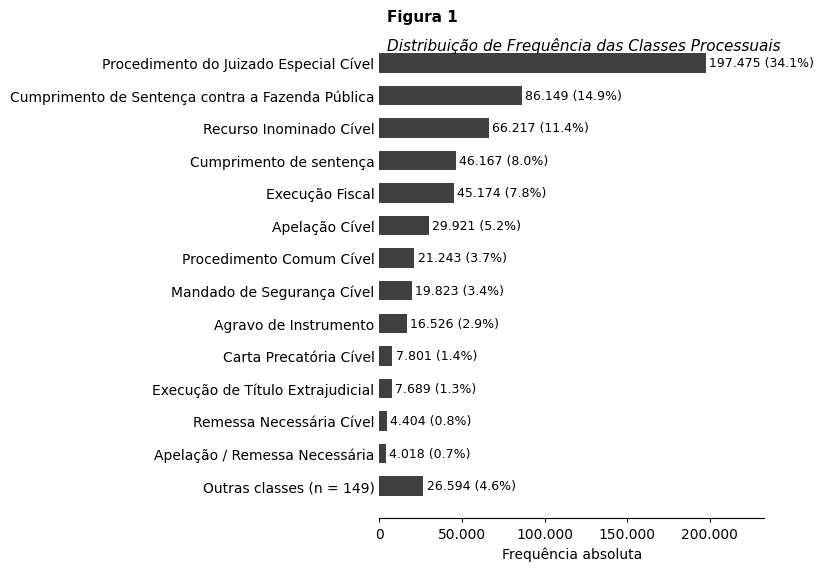

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ============================================================
# 1. TABELA DE FREQUÊNCIA (absoluta, relativa, acumulada, corte 95%)
# ============================================================

freq = df_classe['classe_nome'].value_counts().reset_index()
freq.columns = ['classe_nome', 'freq_absoluta']
freq = freq.sort_values('freq_absoluta', ascending=False).reset_index(drop=True)

total = freq['freq_absoluta'].sum()
freq['freq_relativa_pct'] = freq['freq_absoluta'] / total * 100
freq['freq_acumulada_pct'] = freq['freq_relativa_pct'].cumsum()

# Ponto de corte: primeira classe cuja frequência acumulada atinge/ultrapassa 95%
corte_idx = freq.index[freq['freq_acumulada_pct'] >= 95].min()

if pd.isna(corte_idx):
    freq_top = freq.copy()
    freq_outras = pd.DataFrame(columns=freq.columns)
else:
    freq_top = freq.loc[:corte_idx].copy()
    freq_outras = freq.loc[corte_idx + 1:].copy()

n_classes_agrupadas = len(freq_outras)

if n_classes_agrupadas > 0:
    linha_outras = pd.DataFrame({
        'classe_nome': [f'Outras classes (n = {n_classes_agrupadas})'],
        'freq_absoluta': [freq_outras['freq_absoluta'].sum()],
        'freq_relativa_pct': [freq_outras['freq_relativa_pct'].sum()],
        'freq_acumulada_pct': [100.0],
    })
    tabela_final = pd.concat([freq_top, linha_outras], ignore_index=True)
else:
    tabela_final = freq_top.copy()

tabela_final['freq_relativa_pct'] = tabela_final['freq_relativa_pct'].round(2)
tabela_final['freq_acumulada_pct'] = tabela_final['freq_acumulada_pct'].round(2)

print(f"Classes até 95% acumulado: {len(freq_top)}")
print(f"Classes agrupadas em 'Outras': {n_classes_agrupadas}")
print(f"\n{tabela_final}")

# ============================================================
# 2. CONFIGURAÇÃO DE ESTILO — APA 7ª EDIÇÃO
# ============================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.grid'] = False

APA_COR_BARRA = '#404040'

# ============================================================
# 3. GRÁFICO DE BARRAS HORIZONTAIS
# ============================================================

# Mantém a ordem de frequência acumulada (Outras classes já é a última linha
# de tabela_final) e apenas inverte para o plot, garantindo que Outras fique
# na base do gráfico e a classe mais frequente fique no topo.
dados_grafico = tabela_final.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(dados_grafico))))

bars = ax.barh(
    dados_grafico['classe_nome'],
    dados_grafico['freq_absoluta'],
    color=APA_COR_BARRA,
    height=0.6,
    edgecolor='none',
)

# Rótulos diretos (n e %) ao final de cada barra
for bar, n, pct in zip(bars, dados_grafico['freq_absoluta'], dados_grafico['freq_relativa_pct']):
    ax.text(
        bar.get_width() + (dados_grafico['freq_absoluta'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{n:,.0f} ({pct:.1f}%)'.replace(',', '.'),
        va='center', ha='left', fontsize=9, color='black'
    )

ax.spines['bottom'].set_color('black')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=3)
ax.set_xlim(0, dados_grafico['freq_absoluta'].max() * 1.18)
ax.set_xlabel('Frequência absoluta', fontsize=10)
ax.set_ylabel('')

# Cabeçalho no formato APA: "Figura N" (negrito) + título (itálico)
fig.text(0.02, 1.02, 'Figura 1', fontsize=11, fontweight='bold', transform=ax.transAxes)
fig.text(0.02, 0.96, 'Distribuição de Frequência das Classes Processuais',
          fontsize=11, fontstyle='italic', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Processed/figura1_classes_processuais.png',
            dpi=300, bbox_inches='tight')
plt.show()